# Glucodensity Temporal Mixture: Walkthrough

Temporal mixture models on CGM data with three representations:
1. **L² curves** — intraday glucose on a cosine basis
2. **Correlation matrices** — inter-hour correlation in Sym(24)
3. **Graph signals** — hourly glucose on a correlation-derived graph

Each is fit with time-varying cluster weights π(t) via MMD² minimisation.

In [1]:
import os, sys
import matplotlib.pyplot as plt
import numpy as np
import torch

project_root = os.path.abspath("")
if not os.path.exists(os.path.join(project_root, "src")):
    project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

from examples.train_glucodensity_temporal import (
    CONTROL_IDS, TREATMENT_IDS,
    load_and_preprocess_cgm, compute_sliding_windows,
    build_training_representation, run_experiment,
)
from examples.train_glucodensity_correlation import (
    compute_sliding_window_correlations,
    build_temporal_coefficients,
    estimate_sigma_median_heuristic,
)
from examples.train_glucodensity_correlation_graph import (
    compute_sliding_window_hourly, compute_mean_correlation,
    threshold_to_adjacency,
)
from src import GaussianKernel, GraphLaplacianBasis, SymmetricMatrixBasis
from src.spaces import L2CosineBasis
from src.temporal_mixture import BasisLogitsTimeWeights, NeuralODETimeWeights

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
torch.manual_seed(42); np.random.seed(42)
device, dtype = torch.device("cpu"), torch.float64

K = 2        # mixture components
N_BINS = 16  # temporal bins
EPOCHS = 400
LR = 0.01

csv_path = os.path.join(project_root, "data/glucodensities/cgm_all_patients.csv")
patient_data = load_and_preprocess_cgm(csv_path, max_prop_missing=0.20, block_size=4, verbose=True)

/home/dani/projects/mixture/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Total days: 23760 → after rule 1 (prop_missing ≤ 0.2): 22772
  After value clipping & patient block filter: 22771 days, 98 patients
  Patients removed: 1


## 1. Data: mean hourly glucose surface

3D view of glucose across 24 hours and treatment weeks, split by group.

/home/dani/projects/mixture/examples/train_glucodensity_temporal.py:181: RuntimeWarning: Mean of empty slice
  avg_curve = np.nanmean(window, axis=0)  # (288,)


  Sliding windows (size=4, stride=1):
    Total windows: 22477
    Patients contributing: 98
    Glucose range: [45.3, 396.0]
    Median patient days: 248


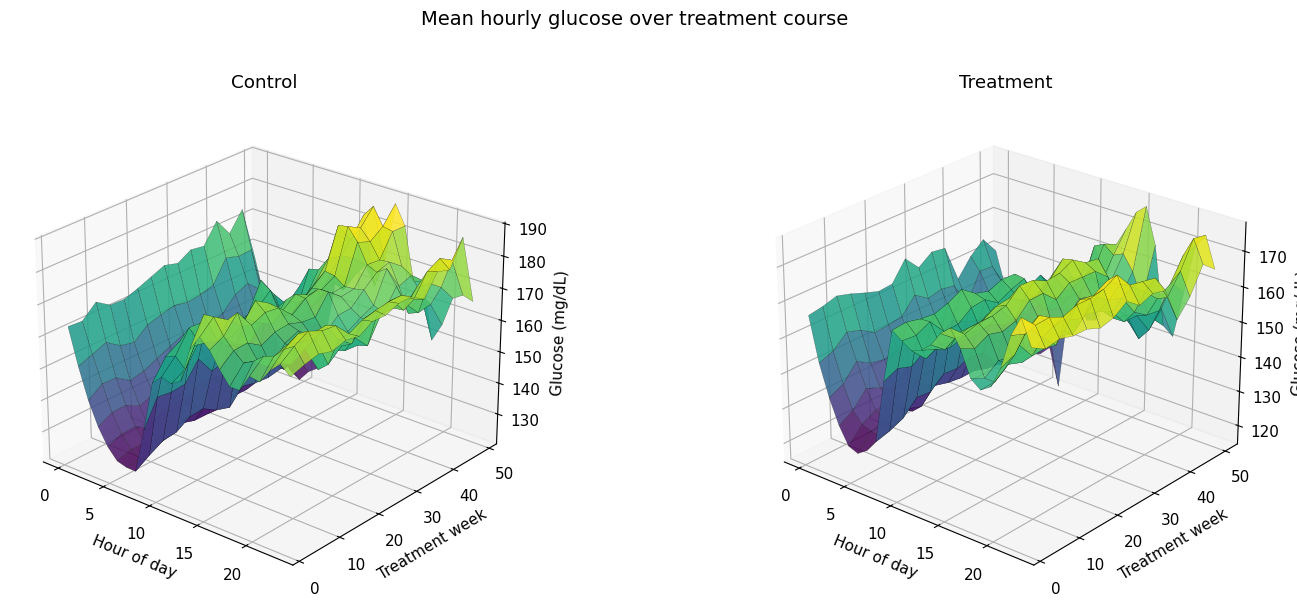

In [2]:
curves, t_indices, pids, wdays, _ = compute_sliding_windows(
    patient_data, window_size=4, stride=1, verbose=True
)
hourly_all = curves.reshape(curves.shape[0], 24, 12).mean(axis=2)
weeks = t_indices / 7.0

ctrl_mask = np.array([p in CONTROL_IDS for p in pids])
treat_mask = np.array([p in TREATMENT_IDS for p in pids])

def make_surface(mask, n_bins=15):
    w, h = weeks[mask], hourly_all[mask]
    edges = np.linspace(w.min(), w.max() + 0.01, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, np.array([
        h[(w >= edges[i]) & (w < edges[i + 1])].mean(0) for i in range(n_bins)
    ])

fig = plt.figure(figsize=(16, 6))
hours = np.arange(24)
for i, (mask, title) in enumerate([(ctrl_mask, "Control"), (treat_mask, "Treatment")]):
    centers, surf = make_surface(mask)
    H, W = np.meshgrid(hours, centers)
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.plot_surface(H, W, surf, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.15)
    ax.set(xlabel="Hour of day", ylabel="Treatment week", zlabel="Glucose (mg/dL)")
    ax.set_title(title)
    ax.view_init(elev=25, azim=-50)
plt.suptitle("Mean hourly glucose over treatment course", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

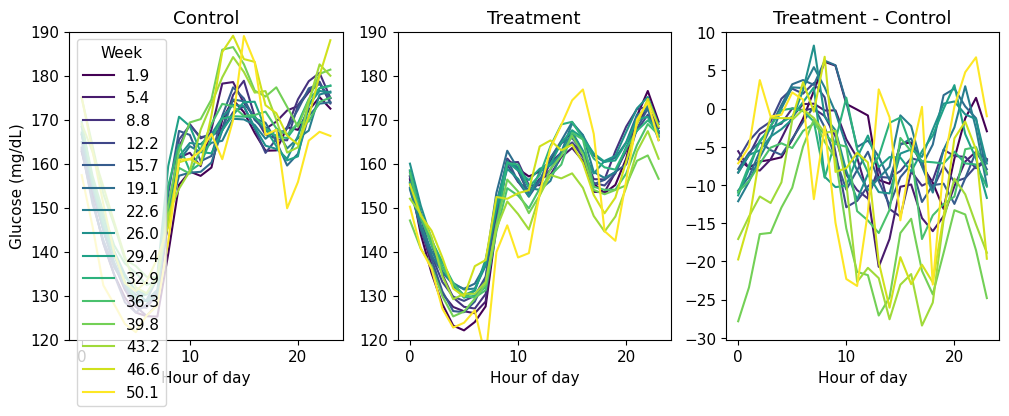

In [3]:
# 1. Choose your colormap
cmap = plt.get_cmap('viridis') 

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

centers, surf_ctrl = make_surface(ctrl_mask)
centers, surf_treat = make_surface(treat_mask)

# 2. Loop through each column and plot
for i in range(surf_ctrl.shape[0]):
    # Use i / (num_lines - 1) to get a value between 0 and 1 for the cmap
    
    color = cmap(i / max(1, surf_ctrl.shape[0] - 1))
    axes[0].plot(hours, surf_ctrl[i, :], color=color, label=f'{centers[i]:.1f}')

    axes[1].plot(hours, surf_treat[i, :], color=color)

    axes[0].set_ylim(120, 190)
    axes[1].set_ylim(120, 190)

    axes[0].set_xlabel('Hour of day')
    axes[0].set_ylabel('Glucose (mg/dL)')
    axes[0].set_title('Control')
    axes[1].set_xlabel('Hour of day')
    axes[1].set_title('Treatment')
    axes[0].legend(title='Week', loc='upper left')

    axes[2].set_xlabel('Hour of day')
    axes[2].set_title('Treatment - Control')
    axes[2].plot(hours, surf_treat[i, :]-surf_ctrl[i, :], color=color, label=f'{centers[i]:.1f}')

In [4]:
hourly_all.shape

(22477, 24)

## 2. Temporal mixture on L² curves

Intraday glucose profiles projected onto a cosine basis.
We compare **NeuralODE** vs **Cosine basis** for the time-varying weights π(t).

  Temporal binning: 16 requested, 16 non-empty
  Day range: [1.5, 362.5]
  Bin sizes (valid samples): min=80, max=2223, median=1610
  Padded to n_max=2223
  X_time_raw shape: (16, 2223, 288)
  Space metric: H1
Epoch   50/400: MMD²(avg_t) = 0.008623
Epoch  100/400: MMD²(avg_t) = 0.005770
Epoch  150/400: MMD²(avg_t) = 0.004471
Epoch  200/400: MMD²(avg_t) = 0.004013
Epoch  250/400: MMD²(avg_t) = 0.003784
Epoch  300/400: MMD²(avg_t) = 0.003718
Epoch  350/400: MMD²(avg_t) = 0.003703
Epoch  400/400: MMD²(avg_t) = 0.003697
NeuralODE final MMD²(avg_t): 0.003697
NeuralODE mean pi over t: [0.2923417 0.7076583]
Epoch   50/400: MMD²(avg_t) = 0.004282
Epoch  100/400: MMD²(avg_t) = 0.003858
Epoch  150/400: MMD²(avg_t) = 0.003778
Epoch  200/400: MMD²(avg_t) = 0.003733
Epoch  250/400: MMD²(avg_t) = 0.003708
Epoch  300/400: MMD²(avg_t) = 0.003699
Epoch  350/400: MMD²(avg_t) = 0.003696
Epoch  400/400: MMD²(avg_t) = 0.003695
CosineBasis final MMD²(avg_t): 0.003695
CosineBasis mean pi over t: [0.72774792 

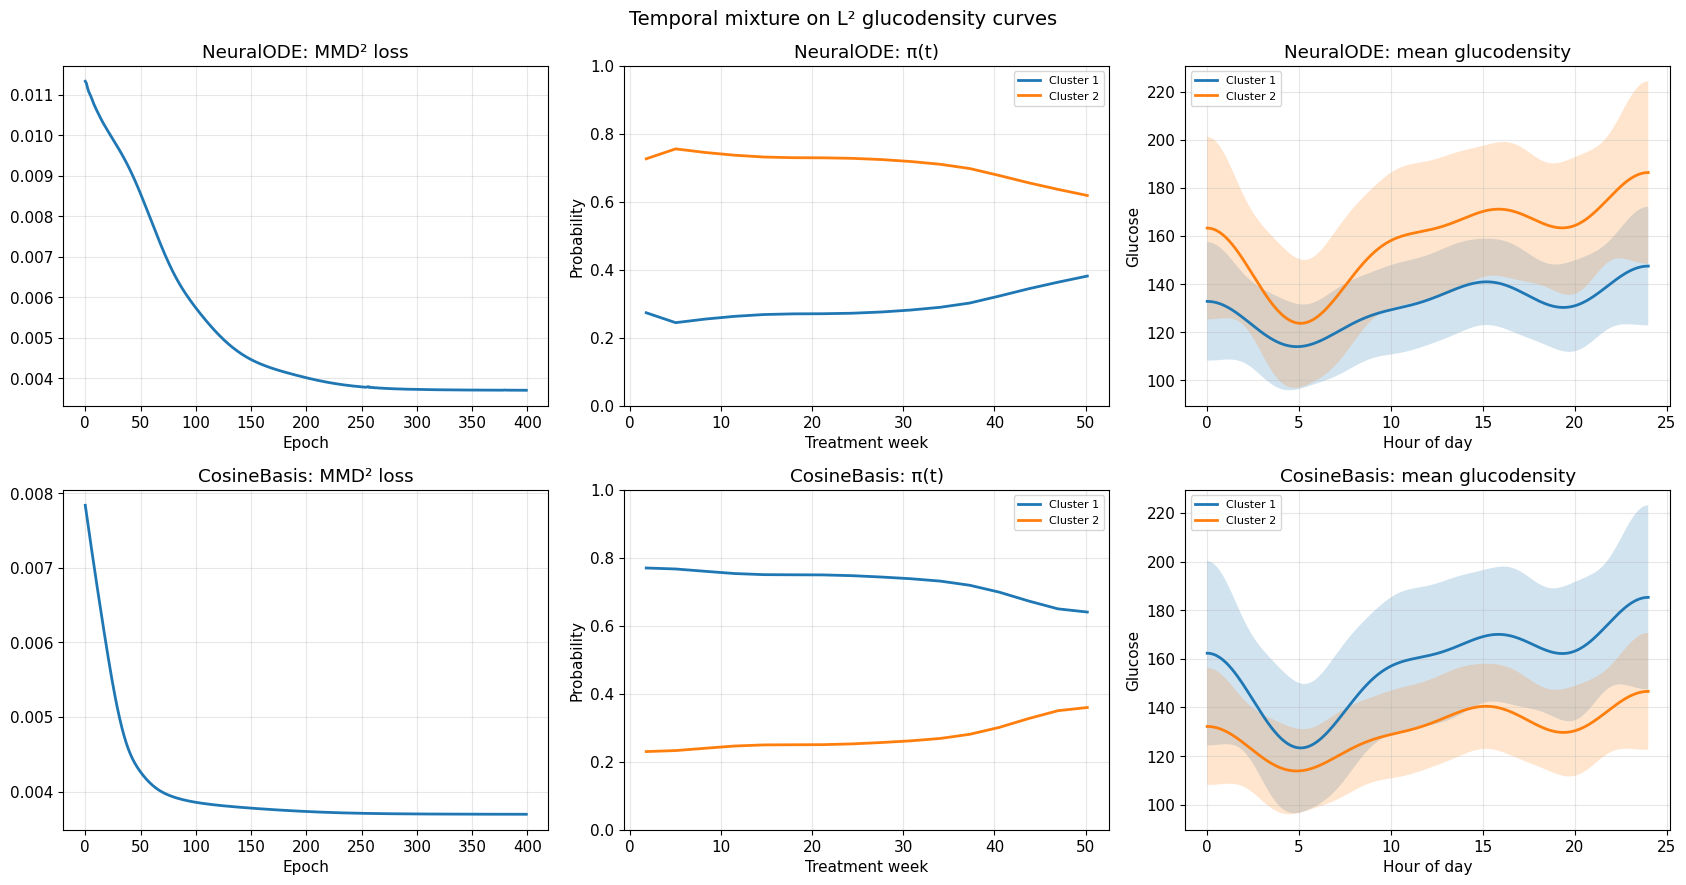

In [5]:
rep = build_training_representation(
    curves, t_indices, n_time_bins=N_BINS, r_s=8, device=device, dtype=dtype, verbose=True, space_metric="h1"
)
X_time, t_grid, mask = rep["X_time"], rep["t_grid"], rep["mask"]
kernel = GaussianKernel(sigma=0.8) #sigma=max(1e-8, rep["sigma_auto"]))

def train_and_extract(name, tw_model):
    model, history, pi_t = run_experiment(
        name, tw_model, X_time, kernel, K, rep["coeff_dim"],
        EPOCHS, LR, device, dtype, mask, verbose=True,
    )
    with torch.no_grad():
        means = model.mean.cpu() * rep["coeff_std"].cpu() + rep["coeff_mean"].cpu()
        recon = rep["space_basis"].reconstruct(means).squeeze(-1).numpy()

        # Function-space std: propagate covariance through de-standardization + basis reconstruction
        cov_std = model.covariance.cpu()  # (K, M, M)
        s = rep["coeff_std"].cpu()        # (M,)
        M = cov_std.shape[1]
        I_M = torch.eye(M, dtype=s.dtype)
        B_raw = rep["space_basis"].reconstruct(I_M).squeeze(-1)  # (M, L)
        B_eff = B_raw * s[:, None]  # effective basis scaled by coeff_std
        std_curves = np.zeros((K, B_raw.shape[1]))
        for k in range(K):
            var_f = ((cov_std[k] @ B_eff) * B_eff).sum(0)  # (L,)
            std_curves[k] = torch.sqrt(torch.clamp(var_f, min=0)).numpy()
    return model, history, pi_t.cpu().numpy(), recon, std_curves

# NeuralODE
ode_model, ode_h, ode_pi, ode_m, ode_std = train_and_extract(
    "NeuralODE", NeuralODETimeWeights(t_grid, K, hidden_dim=64, device=device, dtype=dtype)
)
# Cosine basis
phi = L2CosineBasis(T=1.0, R=6, grid_size=rep["L_t"], d=1, device=device, dtype=dtype)
bas_model, bas_h, bas_pi, bas_m, bas_std = train_and_extract(
    "CosineBasis", BasisLogitsTimeWeights(phi.Phi, K, device=device, dtype=dtype)
)

# --- Plot both models ---
t_days = t_grid.cpu().numpy() * (rep["t_max_days"] - rep["t_min_days"]) + rep["t_min_days"]
t_weeks = t_days / 7.0
slot_x = np.linspace(0, 24, ode_m.shape[1])

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for row, (h, pi, m, sd, name) in enumerate([
    (ode_h, ode_pi, ode_m, ode_std, "NeuralODE"),
    (bas_h, bas_pi, bas_m, bas_std, "CosineBasis"),
]):
    axes[row, 0].plot(h, lw=2)
    axes[row, 0].set(title=f"{name}: MMD² loss", xlabel="Epoch")
    axes[row, 0].grid(alpha=0.3)

    for k in range(K):
        axes[row, 1].plot(t_weeks, pi[:, k], lw=2, label=f"Cluster {k + 1}")
    axes[row, 1].set(title=f"{name}: π(t)", xlabel="Treatment week", ylabel="Probability", ylim=(0, 1))
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].grid(alpha=0.3)

    for k in range(K):
        axes[row, 2].plot(slot_x, m[k], lw=2, label=f"Cluster {k + 1}")
        axes[row, 2].fill_between(slot_x, m[k] - sd[k], m[k] + sd[k], alpha=0.2)
    axes[row, 2].set(title=f"{name}: mean glucodensity", xlabel="Hour of day", ylabel="Glucose")
    axes[row, 2].legend(fontsize=8)
    axes[row, 2].grid(alpha=0.3)

plt.suptitle("Temporal mixture on L² glucodensity curves", fontsize=14)
plt.tight_layout()
plt.show()

  Sliding windows (size=4, stride=1):
    Total windows: 22477
    Patients contributing: 98
    Glucose range: [45.3, 396.0]
    Median patient days: 248


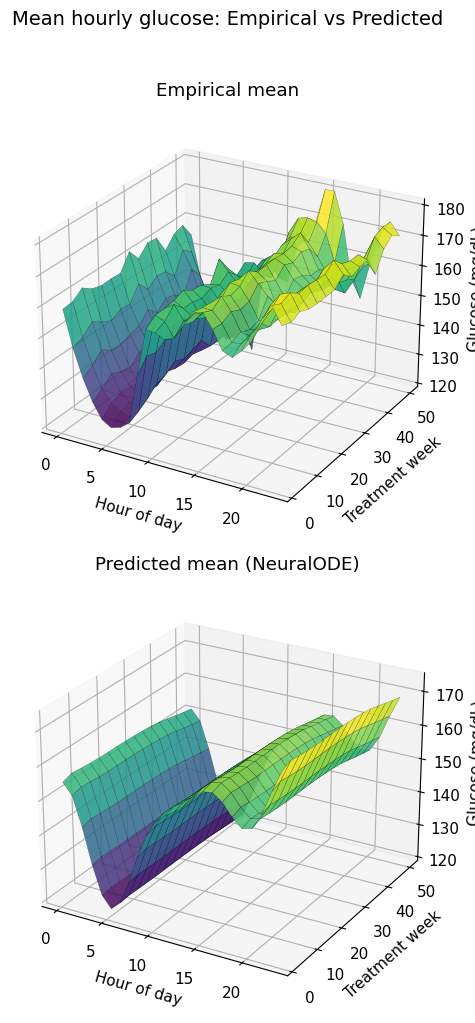

In [6]:
curves, t_indices, pids, wdays, _ = compute_sliding_windows(
    patient_data, window_size=4, stride=1, verbose=True
)
hourly_all = curves.reshape(curves.shape[0], 24, 12).mean(axis=2)
weeks = t_indices / 7.0

def make_surface(n_bins=15):
    w, h = weeks, hourly_all
    edges = np.linspace(w.min(), w.max() + 0.01, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, np.array([
        h[(w >= edges[i]) & (w < edges[i + 1])].mean(0) for i in range(n_bins)
    ])

# Predicted mean surface from the CosineBasis model: mean(t) = sum_k pi_k(t) * mu_k
# slot_x_model = np.linspace(0, 24, bas_m.shape[1])
# bas_m_hourly = np.array([np.interp(np.arange(24), slot_x_model, bas_m[k]) for k in range(K)])
# pred_surface = bas_pi @ bas_m_hourly  # [L_t, 24]

slot_x_model = np.linspace(0, 24, ode_m.shape[1])
ode_m_hourly = np.array([np.interp(np.arange(24), slot_x_model, ode_m[k]) for k in range(K)])
pred_surface = ode_pi @ ode_m_hourly  # [L_t, 24]


fig = plt.figure(figsize=(5, 10))
hours = np.arange(24)

# Left: empirical mean
centers, surf = make_surface()
H, W = np.meshgrid(hours, centers)
ax = fig.add_subplot(2, 1, 1, projection="3d")
ax.plot_surface(H, W, surf, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.15)
ax.set(xlabel="Hour of day", ylabel="Treatment week", zlabel="Glucose (mg/dL)")
ax.set_title("Empirical mean")
ax.view_init(elev=25, azim=-60)

# Right: predicted mean from temporal mixture model
H_pred, W_pred = np.meshgrid(hours, t_weeks)
ax2 = fig.add_subplot(2, 1, 2, projection="3d")
ax2.plot_surface(H_pred, W_pred, pred_surface, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.15)
ax2.set(xlabel="Hour of day", ylabel="Treatment week", zlabel="Glucose (mg/dL)")
ax2.set_title("Predicted mean (NeuralODE)")
ax2.view_init(elev=25, azim=-60)

plt.suptitle("Mean hourly glucose: Empirical vs Predicted", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

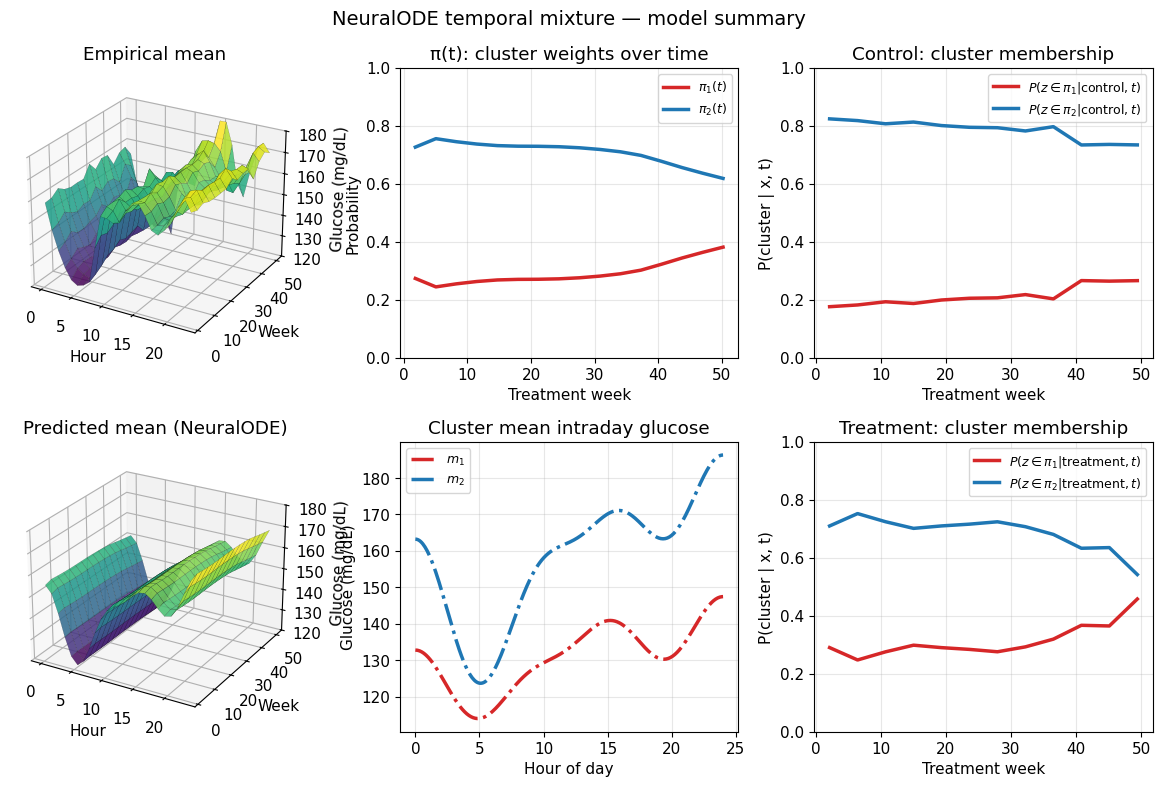

In [7]:
from examples.train_glucodensity_temporal import compute_all_patient_posteriors

# ── Patient posteriors ────────────────────────────────────────────────────────
patient_posteriors, _, patient_time_days_dict = compute_all_patient_posteriors(
    curves=curves,
    t_indices=t_indices,
    patient_ids=pids,
    window_days=wdays,
    model=ode_model,
    space_basis=rep["space_basis"],
    coeff_mean=rep["coeff_mean"],
    coeff_std=rep["coeff_std"],
    t_grid=t_grid,
    t_min_days=rep["t_min_days"],
    t_max_days=rep["t_max_days"],
    device=device,
    dtype=dtype,
)

# ── Bin cluster probabilities per group ──────────────────────────────────────
N_BINS_GRP = 12
ctrl_set = set(CONTROL_IDS)
treat_set = set(TREATMENT_IDS)

ctrl_data, treat_data = [], []
for pid, post in patient_posteriors.items():
    for i, day in enumerate(patient_time_days_dict[pid]):
        entry = (day, post[i])
        if pid in ctrl_set:
            ctrl_data.append(entry)
        elif pid in treat_set:
            treat_data.append(entry)

all_days = [d for d, _ in ctrl_data + treat_data]
bin_edges = np.linspace(min(all_days), max(all_days) + 1e-9, N_BINS_GRP + 1)
bin_weeks = ((bin_edges[:-1] + bin_edges[1:]) / 2.0) / 7.0

def _bin_mean(data):
    binned = [[] for _ in range(N_BINS_GRP)]
    for day, post in data:
        b = max(0, min(int(np.searchsorted(bin_edges, day, side="right")) - 1, N_BINS_GRP - 1))
        binned[b].append(post)
    means = np.full((N_BINS_GRP, K), np.nan)
    for b in range(N_BINS_GRP):
        if binned[b]:
            means[b] = np.array(binned[b]).mean(axis=0)
    return means

ctrl_means_grp = _bin_mean(ctrl_data)
treat_means_grp = _bin_mean(treat_data)

# ── Color scheme ──────────────────────────────────────────────────────────────
# Col 1 (3D surfaces): "plasma" — distinct from earlier "viridis" cells
# Col 2 (π(t) + cluster means): coral / teal per cluster
# Col 3 (group membership): same coral / teal, solid=control dashed=treatment
CLUSTER_COLORS = ["#d62728", "#1f77b4"]   # red, blue — one per cluster
MEAN_COLORS = ["#e377c2", "#17becf"]      # pink, cyan — for predicted mean surface

slot_x_fine = np.linspace(0, 24, ode_m.shape[1])

# ── 3×2 Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 8))

ax00 = fig.add_subplot(2, 3, 1, projection="3d")   # empirical surface
ax10 = fig.add_subplot(2, 3, 4, projection="3d")   # predicted surface
ax01 = fig.add_subplot(2, 3, 2)                    # π(t)
ax11 = fig.add_subplot(2, 3, 5)                    # cluster mean curves
ax02 = fig.add_subplot(2, 3, 3)                    # control cluster probs
ax12 = fig.add_subplot(2, 3, 6)                    # treatment cluster probs

# ── Col 0: Empirical vs Predicted 3D surfaces ─────────────────────────────────
H_emp, W_emp = np.meshgrid(hours, centers)
ax00.plot_surface(H_emp, W_emp, surf, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.1)
ax00.set(xlabel="Hour", ylabel="Week", zlabel="Glucose (mg/dL)")
ax00.set_title("Empirical mean")
ax00.view_init(elev=25, azim=-60)
ax00.set_zlim(120, 180)

H_pred, W_pred = np.meshgrid(hours, t_weeks)
ax10.plot_surface(H_pred, W_pred, pred_surface, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.1)
ax10.set(xlabel="Hour", ylabel="Week", zlabel="Glucose (mg/dL)")
ax10.set_title("Predicted mean (NeuralODE)")
ax10.view_init(elev=25, azim=-60)
ax10.set_zlim(120, 180)

# ── Col 1: π(t) and cluster mean curves ──────────────────────────────────────
for k in range(K):
    ax01.plot(t_weeks, ode_pi[:, k], lw=2.5, color=CLUSTER_COLORS[k], label=f"$\\pi_{{{k + 1}}}(t)$")
ax01.set(title="π(t): cluster weights over time",
         xlabel="Treatment week", ylabel="Probability", ylim=(0, 1))
ax01.legend(fontsize=9)
ax01.grid(alpha=0.3)

for k in range(K):
    ax11.plot(slot_x_fine, ode_m[k], lw=2.5, color=CLUSTER_COLORS[k], label=f"$m_{{{k + 1}}}$", linestyle="dashdot")
ax11.set(title="Cluster mean intraday glucose",
         xlabel="Hour of day", ylabel="Glucose (mg/dL)")
ax11.legend(fontsize=9)
ax11.grid(alpha=0.3)

# ── Col 2: Cluster membership probability by group ────────────────────────────
for k in range(K):
    ok = ~np.isnan(ctrl_means_grp[:, k])
    ax02.plot(bin_weeks[ok], ctrl_means_grp[ok, k], lw=2.5,
              color=CLUSTER_COLORS[k], label=f"$P(z\\in \\pi_{{{k + 1}}} | \\text{{control}}, t)$")
ax02.set(title="Control: cluster membership",
         xlabel="Treatment week", ylabel="P(cluster | x, t)", ylim=(0, 1))
ax02.legend(fontsize=9)
ax02.grid(alpha=0.3)

for k in range(K):
    ok = ~np.isnan(treat_means_grp[:, k])
    ax12.plot(bin_weeks[ok], treat_means_grp[ok, k], lw=2.5,
              color=CLUSTER_COLORS[k], label=f"$P(z\\in \\pi_{{{k + 1}}} | \\text{{treatment}}, t)$")
ax12.set(title="Treatment: cluster membership",
         xlabel="Treatment week", ylabel="P(cluster | x, t)", ylim=(0, 1))
ax12.legend(fontsize=9)
ax12.grid(alpha=0.3)

plt.suptitle("NeuralODE temporal mixture — model summary", fontsize=14)
plt.tight_layout()
plt.savefig("../paper/images/model_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()

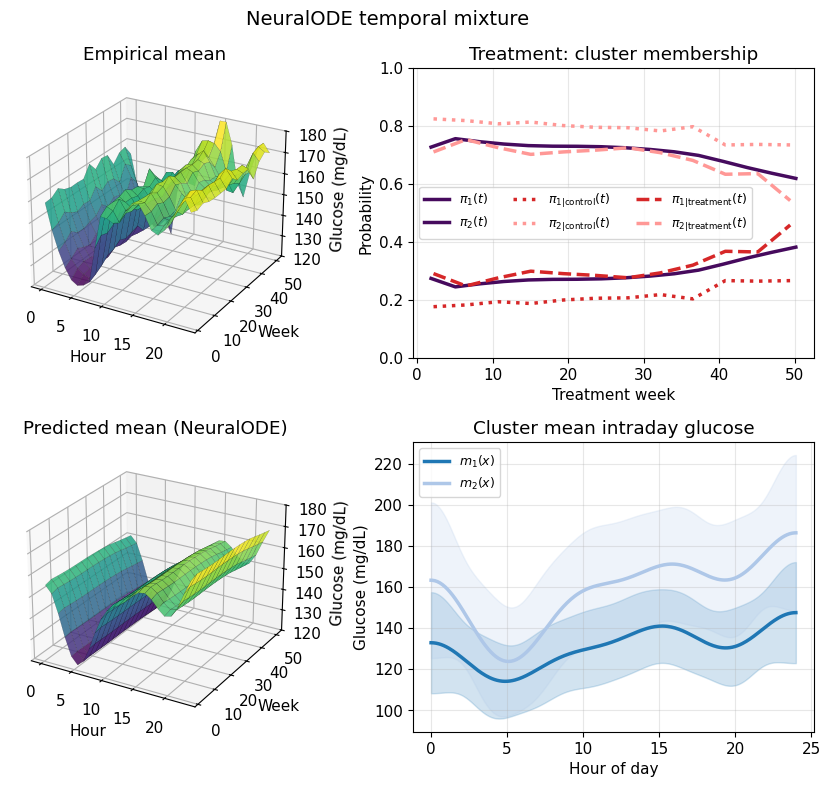

In [8]:
from examples.train_glucodensity_temporal import compute_all_patient_posteriors

# ── Patient posteriors ────────────────────────────────────────────────────────
patient_posteriors, _, patient_time_days_dict = compute_all_patient_posteriors(
    curves=curves,
    t_indices=t_indices,
    patient_ids=pids,
    window_days=wdays,
    model=ode_model,
    space_basis=rep["space_basis"],
    coeff_mean=rep["coeff_mean"],
    coeff_std=rep["coeff_std"],
    t_grid=t_grid,
    t_min_days=rep["t_min_days"],
    t_max_days=rep["t_max_days"],
    device=device,
    dtype=dtype,
)

# ── Bin cluster probabilities per group ──────────────────────────────────────
N_BINS_GRP = 12
ctrl_set = set(CONTROL_IDS)
treat_set = set(TREATMENT_IDS)

ctrl_data, treat_data = [], []
for pid, post in patient_posteriors.items():
    for i, day in enumerate(patient_time_days_dict[pid]):
        entry = (day, post[i])
        if pid in ctrl_set:
            ctrl_data.append(entry)
        elif pid in treat_set:
            treat_data.append(entry)

all_days = [d for d, _ in ctrl_data + treat_data]
bin_edges = np.linspace(min(all_days), max(all_days) + 1e-9, N_BINS_GRP + 1)
bin_weeks = ((bin_edges[:-1] + bin_edges[1:]) / 2.0) / 7.0

def _bin_mean(data):
    binned = [[] for _ in range(N_BINS_GRP)]
    for day, post in data:
        b = max(0, min(int(np.searchsorted(bin_edges, day, side="right")) - 1, N_BINS_GRP - 1))
        binned[b].append(post)
    means = np.full((N_BINS_GRP, K), np.nan)
    for b in range(N_BINS_GRP):
        if binned[b]:
            means[b] = np.array(binned[b]).mean(axis=0)
    return means

ctrl_means_grp = _bin_mean(ctrl_data)
treat_means_grp = _bin_mean(treat_data)

# ── Color scheme ──────────────────────────────────────────────────────────────
# Col 1 (3D surfaces): "plasma" — distinct from earlier "viridis" cells
# Col 2 (π(t) + cluster means): coral / teal per cluster
# Col 3 (group membership): same coral / teal, solid=control dashed=treatment
CLUSTER_COLORS = ["#d62728", "#1f77b4"]   # red, blue — one per cluster
MEAN_COLORS = ["#e377c2", "#17becf"]      # pink, cyan — for predicted mean surface

slot_x_fine = np.linspace(0, 24, ode_m.shape[1])

# ── 3×2 Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(9,8))

ax00 = fig.add_subplot(2, 2, 1, projection="3d")   # empirical surface
ax10 = fig.add_subplot(2, 2, 3, projection="3d")   # predicted surface
ax01 = fig.add_subplot(2, 2, 2)                    # π(t)
ax11 = fig.add_subplot(2, 2, 4)                    # cluster mean curves

# ── Col 0: Empirical vs Predicted 3D surfaces ─────────────────────────────────
H_emp, W_emp = np.meshgrid(hours, centers)
ax00.plot_surface(H_emp, W_emp, surf, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.1)
ax00.set(xlabel="Hour", ylabel="Week", zlabel="Glucose (mg/dL)")
ax00.set_title("Empirical mean")
ax00.view_init(elev=25, azim=-60)
ax00.set_zlim(120, 180)

H_pred, W_pred = np.meshgrid(hours, t_weeks)
ax10.plot_surface(H_pred, W_pred, pred_surface, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.1)
ax10.set(xlabel="Hour", ylabel="Week", zlabel="Glucose (mg/dL)")
ax10.set_title("Predicted mean (NeuralODE)")
ax10.view_init(elev=25, azim=-60)
ax10.set_zlim(120, 180)

# ── Col 1: π(t) and cluster mean curves ──────────────────────────────────────
for k in range(K):
    ax01.plot(t_weeks, ode_pi[:, k], lw=2.5, color=cmap(6+k), label=f"$\\pi_{{{k + 1}}}(t)$")
ax01.set(title="π(t): cluster weights over time",
         xlabel="Treatment week", ylabel="Probability", ylim=(0, 1))
ax01.legend(fontsize=9)
ax01.grid(alpha=0.3)

import matplotlib
cmap = matplotlib.colormaps.get_cmap('tab20')
for k in range(K):
    ax11.plot(slot_x_fine, ode_m[k], lw=2.5, color=cmap(k), label=f"$m_{{{k + 1}}}(x)$")
    ax11.fill_between(slot_x_fine, ode_m[k] - ode_std[k], ode_m[k] + ode_std[k],
                      color=cmap(k), alpha=0.2)
ax11.set(title="Cluster mean intraday glucose",
         xlabel="Hour of day", ylabel="Glucose (mg/dL)")
ax11.legend(fontsize=9)
ax11.grid(alpha=0.3)

# ── Col 2: Cluster membership probability by group ────────────────────────────
for k in range(K):
    ok = ~np.isnan(ctrl_means_grp[:, k])
    ax01.plot(bin_weeks[ok], ctrl_means_grp[ok, k], lw=2.5,
              color=cmap(6+k), label=f"$\\pi_{{{k + 1}| \\text{{control}}}}(t)$", linestyle=":")
ax01.set(title="Control: cluster membership",
         xlabel="Treatment week", ylim=(0, 1))
ax01.legend(fontsize=9)
ax01.grid(alpha=0.3)

for k in range(K):
    ok = ~np.isnan(treat_means_grp[:, k])
    ax01.plot(bin_weeks[ok], treat_means_grp[ok, k], lw=2.5,
              color=cmap(6+k), label=f"$\\pi_{{{k + 1}| \\text{{treatment}}}}(t)$", linestyle="dashed")
ax01.set(title="Treatment: cluster membership",
         xlabel="Treatment week", ylim=(0, 1))
ax01.legend(fontsize=9, ncols=3)
ax01.grid(alpha=0.3)

plt.suptitle("NeuralODE temporal mixture", fontsize=14)
plt.tight_layout()
plt.savefig("../paper/images/model_summary_v2.pdf", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_290704/2435728797.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


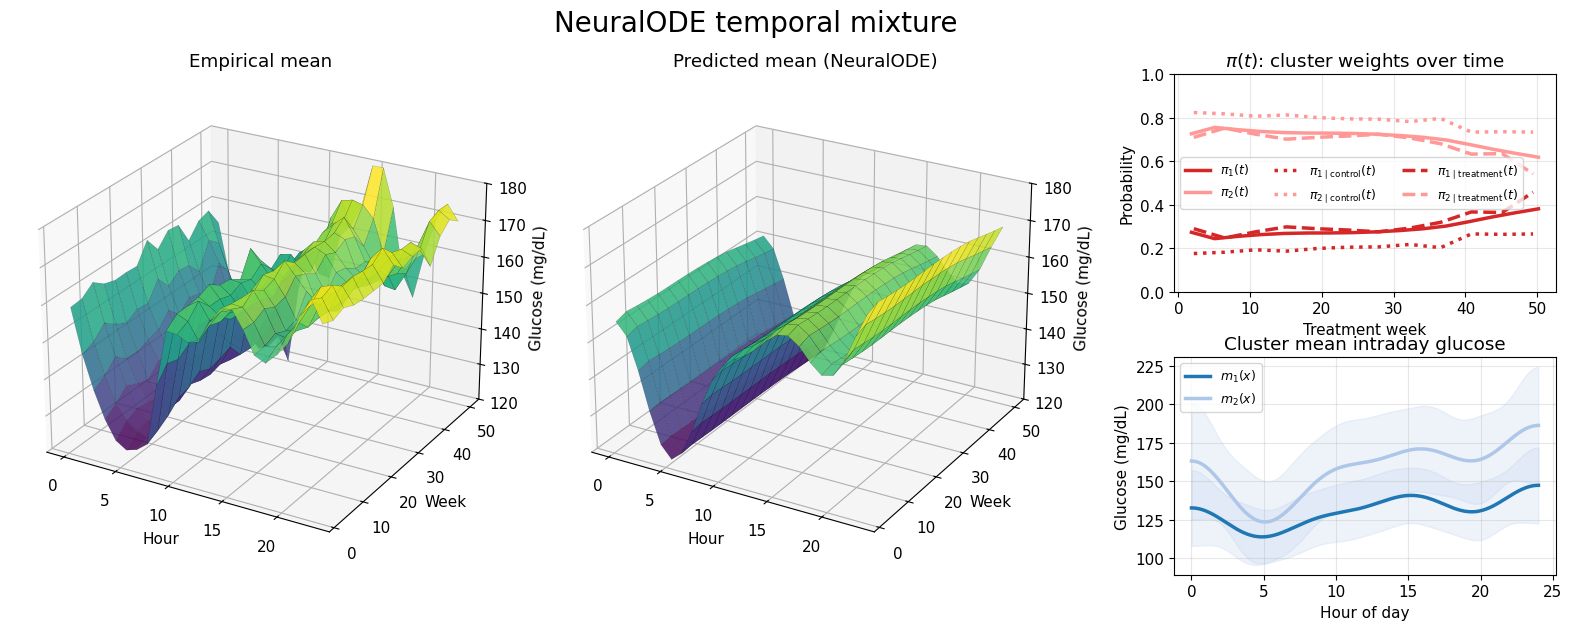

In [9]:
from examples.train_glucodensity_temporal import compute_all_patient_posteriors
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import gridspec

# ── Patient posteriors ────────────────────────────────────────────────────────
patient_posteriors, _, patient_time_days_dict = compute_all_patient_posteriors(
    curves=curves,
    t_indices=t_indices,
    patient_ids=pids,
    window_days=wdays,
    model=ode_model,
    space_basis=rep["space_basis"],
    coeff_mean=rep["coeff_mean"],
    coeff_std=rep["coeff_std"],
    t_grid=t_grid,
    t_min_days=rep["t_min_days"],
    t_max_days=rep["t_max_days"],
    device=device,
    dtype=dtype,
)

# ── Bin cluster probabilities per group ──────────────────────────────────────
N_BINS_GRP = 12
ctrl_set = set(CONTROL_IDS)
treat_set = set(TREATMENT_IDS)

ctrl_data, treat_data = [], []
for pid, post in patient_posteriors.items():
    for i, day in enumerate(patient_time_days_dict[pid]):
        entry = (day, post[i])
        if pid in ctrl_set:
            ctrl_data.append(entry)
        elif pid in treat_set:
            treat_data.append(entry)

all_days = [d for d, _ in ctrl_data + treat_data]
bin_edges = np.linspace(min(all_days), max(all_days) + 1e-9, N_BINS_GRP + 1)
bin_weeks = ((bin_edges[:-1] + bin_edges[1:]) / 2.0) / 7.0

def _bin_mean(data):
    binned = [[] for _ in range(N_BINS_GRP)]
    for day, post in data:
        b = max(0, min(int(np.searchsorted(bin_edges, day, side="right")) - 1, N_BINS_GRP - 1))
        binned[b].append(post)
    means = np.full((N_BINS_GRP, K), np.nan)
    for b in range(N_BINS_GRP):
        if binned[b]:
            means[b] = np.array(binned[b]).mean(axis=0)
    return means

ctrl_means_grp = _bin_mean(ctrl_data)
treat_means_grp = _bin_mean(treat_data)

# ── Color scheme ──────────────────────────────────────────────────────────────
CLUSTER_COLORS = ["#d62728", "#1f77b4"]   # red, blue
MEAN_COLORS = ["#e377c2", "#17becf"]      # pink, cyan

cmap = matplotlib.colormaps.get_cmap("tab20")
slot_x_fine = np.linspace(0, 24, ode_m.shape[1])

# ── Figure layout: 2 rows × 3 cols ───────────────────────────────────────────
# Col 1: empirical 3D
# Col 2: predicted 3D
# Col 3: top=π(t), bottom=group membership / cluster means
fig = plt.figure(figsize=(20, 6.5))
gs = gridspec.GridSpec(
    2, 4,
    width_ratios=[1.2, 1.2, 0.1, 0.9],  # third entry is spacer width
    height_ratios=[1, 1],
    wspace=0.1,
    hspace=0.30,
)

ax_emp   = fig.add_subplot(gs[:, 0], projection="3d")
ax_pred  = fig.add_subplot(gs[:, 1], projection="3d")
# gs[:, 2] is intentionally unused as spacer
ax_pi    = fig.add_subplot(gs[0, 3])
ax_group = fig.add_subplot(gs[1, 3])

# ── Col 1: Empirical 3D surface ──────────────────────────────────────────────
H_emp, W_emp = np.meshgrid(hours, centers)
ax_emp.plot_surface(
    H_emp, W_emp, surf,
    cmap="viridis",
    alpha=0.85,
    edgecolor="k",
    linewidth=0.1
)
ax_emp.set_xlabel("Hour")
ax_emp.set_ylabel("Week")
ax_emp.set_zlabel("Glucose (mg/dL)")
ax_emp.set_title("Empirical mean")
ax_emp.view_init(elev=25, azim=-60)
ax_emp.set_zlim(120, 180)

# ── Col 2: Predicted 3D surface ──────────────────────────────────────────────
H_pred, W_pred = np.meshgrid(hours, t_weeks)
ax_pred.plot_surface(
    H_pred, W_pred, pred_surface,
    cmap="viridis",
    alpha=0.85,
    edgecolor="k",
    linewidth=0.1
)
ax_pred.set_xlabel("Hour")
ax_pred.set_ylabel("Week")
ax_pred.set_zlabel("Glucose (mg/dL)")
ax_pred.set_title("Predicted mean (NeuralODE)")
ax_pred.view_init(elev=25, azim=-60)
ax_pred.set_zlim(120, 180)

# ── Col 3, Row 1: π(t) ───────────────────────────────────────────────────────
for k in range(K):
    ax_pi.plot(
        t_weeks,
        ode_pi[:, k],
        lw=2.5,
        color=cmap(6 + k),
        label=fr"$\pi_{{{k + 1}}}(t)$"
    )

ax_pi.set_title(r"$\pi(t)$: cluster weights over time")
ax_pi.set_xlabel("Treatment week")
ax_pi.set_ylabel("Probability")
ax_pi.set_ylim(0, 1)
ax_pi.grid(alpha=0.3)


# ── Col 3, Row 2: group membership probabilities ─────────────────────────────
for k in range(K):
    ok = ~np.isnan(ctrl_means_grp[:, k])
    ax_pi.plot(
        bin_weeks[ok],
        ctrl_means_grp[ok, k],
        lw=2.5,
        color=cmap(6 + k),
        linestyle=":",
        label=fr"$\pi_{{{k + 1}\mid \mathrm{{control}}}}(t)$"
    )

for k in range(K):
    ok = ~np.isnan(treat_means_grp[:, k])
    ax_pi.plot(
        bin_weeks[ok],
        treat_means_grp[ok, k],
        lw=2.5,
        color=cmap(6 + k),
        linestyle="--",
        label=fr"$\pi_{{{k + 1}\mid \mathrm{{treatment}}}}(t)$"
    )

ax_pi.legend(fontsize=9, ncols=3)
# ax_group.set_title("Cluster membership by group")
# ax_group.set_xlabel("Treatment week")
# ax_group.set_ylabel("Probability")
# ax_group.set_ylim(0, 1)
# ax_group.grid(alpha=0.3)
# ax_group.legend(fontsize=8, ncols=1)

# bottom-right: cluster means
for k in range(K):
    ax_group.plot(slot_x_fine, ode_m[k], lw=2.5, color=cmap(k), label=fr"$m_{{{k + 1}}}(x)$")
    ax_group.fill_between(slot_x_fine, ode_m[k] - ode_std[k], ode_m[k] + ode_std[k],
                      color=cmap(1), alpha=0.2)
ax_group.set_title("Cluster mean intraday glucose")
ax_group.set_xlabel("Hour of day")
ax_group.set_ylabel("Glucose (mg/dL)")
ax_group.grid(alpha=0.3)
ax_group.legend(fontsize=9, loc="upper left")

plt.suptitle("NeuralODE temporal mixture", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../paper/images/model_summary_v3.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 2.1 Total Variation Distance Between Groups

We quantify the divergence between the control and treatment arms via the **total variation (TV) distance** between their group-level posterior distributions at each time bin:

$$\mathrm{TV}(t) = \tfrac{1}{2}\|\bar{\gamma}_{\mathrm{treat}}(t) - \bar{\gamma}_{\mathrm{ctrl}}(t)\|_1$$

where $\bar{\gamma}_{g,k}(t)$ is the average posterior probability of cluster $k$ across all patients in group $g$ at time $t$.
TV = 0 means identical cluster usage; TV = 1 means complete separation.

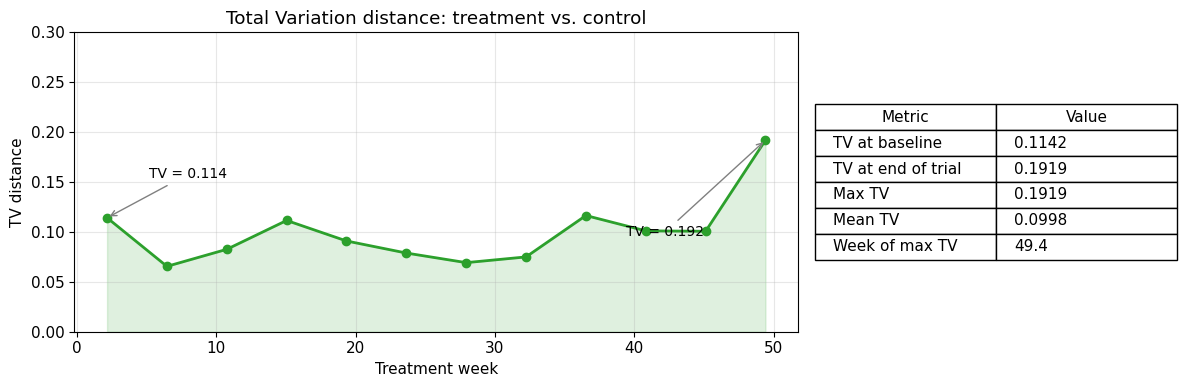


TV distance per time bin:
  Week   2.1: TV = 0.1142
  Week   6.4: TV = 0.0655
  Week  10.7: TV = 0.0826
  Week  15.0: TV = 0.1115
  Week  19.3: TV = 0.0909
  Week  23.6: TV = 0.0788
  Week  27.9: TV = 0.0692
  Week  32.2: TV = 0.0750
  Week  36.5: TV = 0.1164
  Week  40.8: TV = 0.1011
  Week  45.1: TV = 0.1006
  Week  49.4: TV = 0.1919


In [10]:
# ── Total Variation distance between control and treatment ────────────────────
# Reuses ctrl_means_grp, treat_means_grp, bin_weeks from the cell above.

tv_distance = 0.5 * np.abs(treat_means_grp - ctrl_means_grp).sum(axis=1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [2, 1]})

# Left: TV(t) over time
valid = ~np.isnan(tv_distance)
axes[0].plot(bin_weeks[valid], tv_distance[valid], "o-", lw=2, color="#2ca02c")
axes[0].fill_between(bin_weeks[valid], 0, tv_distance[valid], alpha=0.15, color="#2ca02c")
axes[0].set_xlabel("Treatment week")
axes[0].set_ylabel("TV distance")
axes[0].set_title("Total Variation distance: treatment vs. control")
axes[0].set_ylim(0, max(0.3, tv_distance[valid].max() * 1.2))
axes[0].axhline(0, color="gray", lw=0.5)
axes[0].grid(alpha=0.3)

# Annotate start and end values
axes[0].annotate(
    f"TV = {tv_distance[valid][0]:.3f}",
    xy=(bin_weeks[valid][0], tv_distance[valid][0]),
    xytext=(bin_weeks[valid][0] + 3, tv_distance[valid].max() * 0.8),
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=10,
)
axes[0].annotate(
    f"TV = {tv_distance[valid][-1]:.3f}",
    xy=(bin_weeks[valid][-1], tv_distance[valid][-1]),
    xytext=(bin_weeks[valid][-1] - 10, tv_distance[valid].max() * 0.5),
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=10,
)

# Right: summary statistics table
stats = {
    "Metric": [
        "TV at baseline",
        "TV at end of trial",
        "Max TV",
        "Mean TV",
        "Week of max TV",
    ],
    "Value": [
        f"{tv_distance[valid][0]:.4f}",
        f"{tv_distance[valid][-1]:.4f}",
        f"{tv_distance[valid].max():.4f}",
        f"{tv_distance[valid].mean():.4f}",
        f"{bin_weeks[valid][np.argmax(tv_distance[valid])]:.1f}",
    ],
}
axes[1].axis("off")
table = axes[1].table(
    cellText=list(zip(stats["Metric"], stats["Value"])),
    colLabels=["Metric", "Value"],
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)

plt.tight_layout()
plt.savefig("../paper/images/tv_distance.pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nTV distance per time bin:")
for w, tv in zip(bin_weeks[valid], tv_distance[valid]):
    print(f"  Week {w:5.1f}: TV = {tv:.4f}")

## 3. Correlation matrix model

Sliding-window 24×24 inter-hour correlation matrices, embedded in Sym(24) via scaled vech.

In [ ]:
K=2
corr_mats, corr_t, corr_pids, corr_wd, _ = compute_sliding_window_correlations(
    patient_data, window_size=10, stride=1, shrinkage=0.1, verbose=True
)
sym_basis = SymmetricMatrixBasis(n=24, device=device, dtype=dtype)
corr_coeffs = sym_basis.project(
    torch.tensor(corr_mats, device=device, dtype=dtype)
).detach().cpu().numpy()

corr_rep = build_temporal_coefficients(corr_coeffs, corr_t, N_BINS, device, dtype)
sigma_c = estimate_sigma_median_heuristic(corr_rep["X_time"], corr_rep["mask"])
sigma_c = 1.0

/home/dani/projects/mixture/examples/train_glucodensity_correlation.py:70: RuntimeWarning: Mean of empty slice
  return np.nanmean(reshaped, axis=2)


  Sliding-window correlations (size=14, stride=1):
    Total windows: 21497
    Patients contributing: 98
  Temporal binning: 16 requested, 16 non-empty
  Day range: [6.5, 357.5]
  Bin sizes: min=73, max=2098, median=1515
  Padded to n_max=2098, coeff_dim=36


/home/dani/projects/mixture/examples/train_glucodensity_correlation.py:70: RuntimeWarning: Mean of empty slice
  return np.nanmean(reshaped, axis=2)


  Sliding-window correlations (size=10, stride=1):
    Total windows: 21889
    Patients contributing: 98
  Temporal binning: 16 requested, 16 non-empty
  Day range: [4.5, 359.5]
  Bin sizes: min=80, max=2205, median=1526
  Padded to n_max=2205, coeff_dim=300
Epoch   62/500: MMD²(avg_t) = 0.004934
Epoch  124/500: MMD²(avg_t) = 0.004377
Epoch  186/500: MMD²(avg_t) = 0.004334
Epoch  248/500: MMD²(avg_t) = 0.004323
Epoch  310/500: MMD²(avg_t) = 0.004322
Epoch  372/500: MMD²(avg_t) = 0.004320
Epoch  434/500: MMD²(avg_t) = 0.004320
Epoch  496/500: MMD²(avg_t) = 0.004318
CorrODE final MMD²(avg_t): 0.004318
CorrODE mean pi over t: [0.55258103 0.44741897]


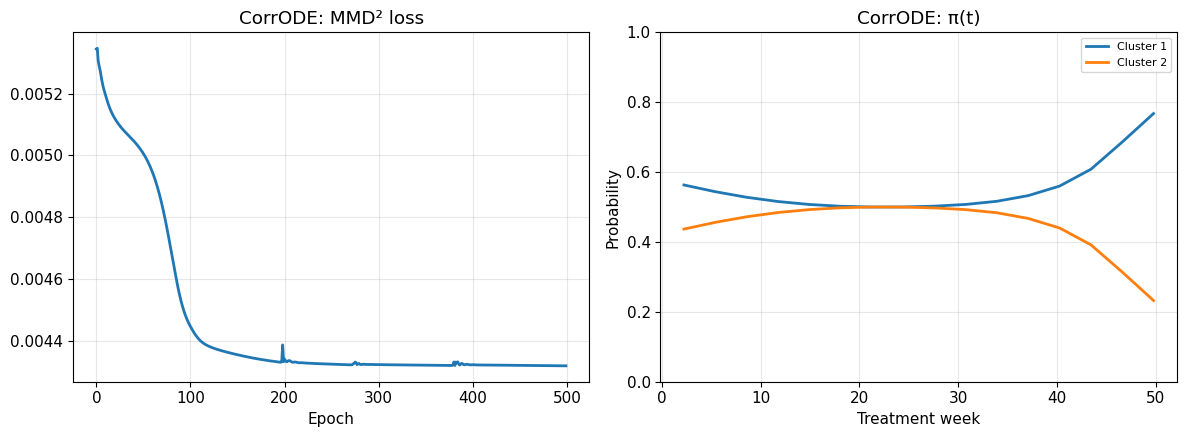

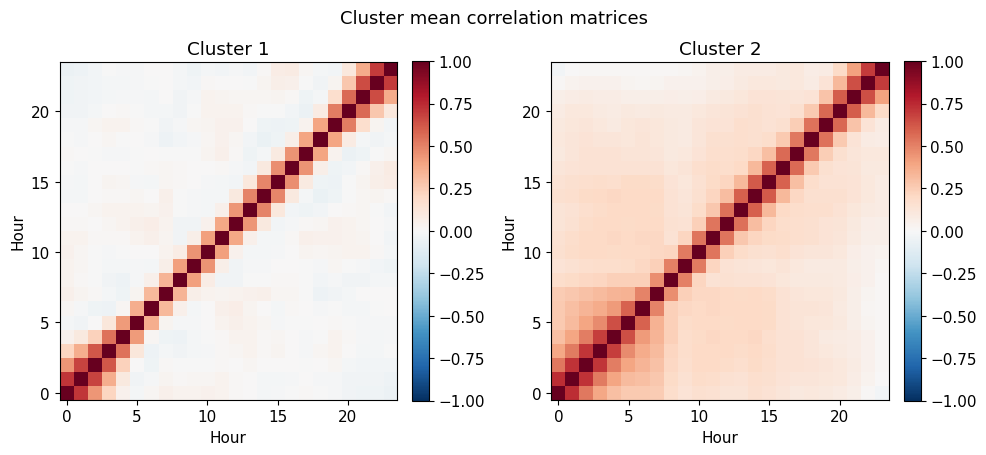

In [38]:
K=2
corr_mats, corr_t, corr_pids, corr_wd, _ = compute_sliding_window_correlations(
    patient_data, window_size=10, stride=1, shrinkage=0.1, verbose=True
)
sym_basis = SymmetricMatrixBasis(n=24, device=device, dtype=dtype)
corr_coeffs = sym_basis.project(
    torch.tensor(corr_mats, device=device, dtype=dtype)
).detach().cpu().numpy()

corr_rep = build_temporal_coefficients(corr_coeffs, corr_t, N_BINS, device, dtype)
sigma_c = estimate_sigma_median_heuristic(corr_rep["X_time"], corr_rep["mask"])
sigma_c = 6.0

model_c, hist_c, pi_c = run_experiment(
    "CorrODE",
    NeuralODETimeWeights(corr_rep["t_grid"], K, hidden_dim=64, device=device, dtype=dtype),
    corr_rep["X_time"], GaussianKernel(sigma=max(1e-8, sigma_c)),
    K, corr_rep["coeff_dim"], EPOCHS+100, LR, device, dtype, corr_rep["mask"], verbose=True,
)

with torch.no_grad():
    recon_corr = sym_basis.reconstruct(
        model_c.mean.cpu() * corr_rep["coeff_std"].cpu() + corr_rep["coeff_mean"].cpu()
    ).numpy()

t_weeks_c = (
    corr_rep["t_grid"].cpu().numpy()
    * (corr_rep["t_max_days"] - corr_rep["t_min_days"]) + corr_rep["t_min_days"]
) / 7.0

# Training curve + π(t)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(hist_c, lw=2)
ax1.set(title="CorrODE: MMD² loss", xlabel="Epoch")
ax1.grid(alpha=0.3)
for k in range(K):
    ax2.plot(t_weeks_c, pi_c.cpu().numpy()[:, k], lw=2, label=f"Cluster {k + 1}")
ax2.set(title="CorrODE: π(t)", xlabel="Treatment week", ylabel="Probability", ylim=(0, 1))
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Cluster mean correlation heatmaps
fig, axes = plt.subplots(1, K, figsize=(5 * K, 4.5))
for k in range(K):
    im = axes[k].imshow(recon_corr[k], cmap="RdBu_r", vmin=-1, vmax=1, origin="lower")
    axes[k].set(title=f"Cluster {k + 1}", xlabel="Hour", ylabel="Hour")
    fig.colorbar(im, ax=axes[k], fraction=0.046, pad=0.04)
plt.suptitle("Cluster mean correlation matrices", fontsize=13)
plt.tight_layout()
plt.show()

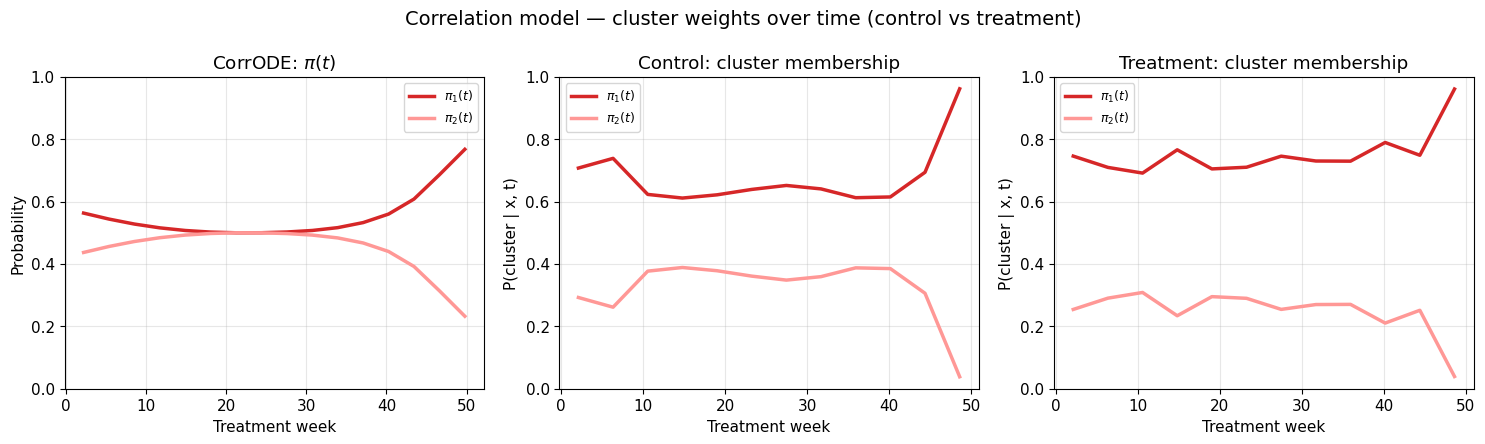

In [39]:
from examples.train_glucodensity_temporal import interpolate_pi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ── Generic posterior helper (works for any basis) ───────────────────────────
def _compute_posteriors_generic(
    raw_data, t_indices, patient_ids, window_days,
    basis, coeff_mean, coeff_std, t_grid, t_min_days, t_max_days,
    model, device, dtype,
):
    """Compute P(k|x,t) for each patient window using pre-computed coeff basis."""
    raw_t = torch.tensor(raw_data, device=device, dtype=dtype)
    all_coeffs = basis.project(raw_t)  # (N, M)
    all_coeffs = (all_coeffs - coeff_mean.unsqueeze(0)) / coeff_std.unsqueeze(0)

    with torch.no_grad():
        pi_t = model.time_weight_model().cpu().numpy()  # (L_t, K)
    t_grid_np = t_grid.cpu().numpy()

    day_range = t_max_days - t_min_days
    if day_range < 1e-9:
        day_range = 1.0

    patient_indices = {}
    for i, pid in enumerate(patient_ids):
        patient_indices.setdefault(pid, []).append(i)

    posteriors_dict, time_days_dict = {}, {}
    for pid, idx_list in patient_indices.items():
        idx = np.array(idx_list)
        x_coeffs = all_coeffs[idx]
        t_abs = t_indices[idx]
        days = window_days[idx]
        t_norm = np.clip((t_abs - t_min_days) / day_range, 0.0, 1.0)
        pi_at_t = torch.tensor(
            interpolate_pi(pi_t, t_grid_np, t_norm), device=device, dtype=dtype
        )
        with torch.no_grad():
            post = model.responsibilities(x_coeffs, pi_at_t)
        posteriors_dict[pid] = post.cpu().numpy()
        time_days_dict[pid] = days

    return posteriors_dict, time_days_dict


# ── Compute posteriors for correlation model ──────────────────────────────────
corr_post, corr_days_dict = _compute_posteriors_generic(
    corr_mats, corr_t, corr_pids, corr_wd,
    sym_basis,
    corr_rep["coeff_mean"], corr_rep["coeff_std"],
    corr_rep["t_grid"], corr_rep["t_min_days"], corr_rep["t_max_days"],
    model_c, device, dtype,
)

# ── Bin by control / treatment ────────────────────────────────────────────────
N_BINS_GRP = 12
ctrl_set = set(CONTROL_IDS)
treat_set = set(TREATMENT_IDS)

ctrl_data_c, treat_data_c = [], []
for pid, post in corr_post.items():
    for i, day in enumerate(corr_days_dict[pid]):
        if pid in ctrl_set:
            ctrl_data_c.append((day, post[i]))
        elif pid in treat_set:
            treat_data_c.append((day, post[i]))

all_days_c = [d for d, _ in ctrl_data_c + treat_data_c]
bin_edges_c = np.linspace(min(all_days_c), max(all_days_c) + 1e-9, N_BINS_GRP + 1)
bin_weeks_c = ((bin_edges_c[:-1] + bin_edges_c[1:]) / 2.0) / 7.0

def _bin_mean_c(data, bin_edges, n_bins, K):
    binned = [[] for _ in range(n_bins)]
    for day, post in data:
        b = max(0, min(int(np.searchsorted(bin_edges, day, side="right")) - 1, n_bins - 1))
        binned[b].append(post)
    means = np.full((n_bins, K), np.nan)
    for b in range(n_bins):
        if binned[b]:
            means[b] = np.array(binned[b]).mean(axis=0)
    return means

ctrl_means_c  = _bin_mean_c(ctrl_data_c,  bin_edges_c, N_BINS_GRP, K)
treat_means_c = _bin_mean_c(treat_data_c, bin_edges_c, N_BINS_GRP, K)

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap_c = matplotlib.colormaps.get_cmap("tab20")
t_weeks_c_plot = (
    corr_rep["t_grid"].cpu().numpy()
    * (corr_rep["t_max_days"] - corr_rep["t_min_days"]) + corr_rep["t_min_days"]
) / 7.0

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Left: global π(t)
for k in range(K):
    axes[0].plot(t_weeks_c_plot, pi_c.cpu().numpy()[:, k], lw=2.5,
                 color=cmap_c(6 + k), label=fr"$\pi_{{{k+1}}}(t)$")
axes[0].set(title=r"CorrODE: $\pi(t)$", xlabel="Treatment week",
            ylabel="Probability", ylim=(0, 1))
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Middle: control group posteriors
for k in range(K):
    ok = ~np.isnan(ctrl_means_c[:, k])
    axes[1].plot(bin_weeks_c[ok], ctrl_means_c[ok, k], lw=2.5,
                 color=cmap_c(6 + k), label=fr"$\pi_{{{k+1}}}(t)$")
axes[1].set(title="Control: cluster membership", xlabel="Treatment week",
            ylabel="P(cluster | x, t)", ylim=(0, 1))
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# Right: treatment group posteriors
for k in range(K):
    ok = ~np.isnan(treat_means_c[:, k])
    axes[2].plot(bin_weeks_c[ok], treat_means_c[ok, k], lw=2.5,
                 color=cmap_c(6 + k), label=fr"$\pi_{{{k+1}}}(t)$")
axes[2].set(title="Treatment: cluster membership", xlabel="Treatment week",
            ylabel="P(cluster | x, t)", ylim=(0, 1))
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle("Correlation model — cluster weights over time (control vs treatment)", fontsize=14)
plt.tight_layout()
plt.savefig("../paper/images/corr_cluster_weights.pdf", dpi=300, bbox_inches="tight")
plt.show()


## 4. Graph Laplacian model

A graph over 24 hours is built from inter-hour correlations.
Each window's hourly glucose is a graph signal projected onto the Laplacian eigenbasis.

/home/dani/projects/mixture/examples/train_glucodensity_correlation_graph.py:71: RuntimeWarning: Mean of empty slice
  return np.nanmean(reshaped, axis=2)


  Mean correlation computed from 21497 windows
  Edges (|corr| > 0.5): 12
  Sliding windows (size=7, stride=1):
    Total windows: 22183
    Patients contributing: 98
    Glucose range: [56.1, 340.4]
  Temporal binning: 16 requested, 16 non-empty
  Day range: [3.0, 361.0]
  Bin sizes: min=80, max=2214, median=1568
  Padded to n_max=2214, coeff_dim=15
Epoch   50/400: MMD²(avg_t) = 0.092969
Epoch  100/400: MMD²(avg_t) = 0.035605
Epoch  150/400: MMD²(avg_t) = 0.014801
Epoch  200/400: MMD²(avg_t) = 0.008749
Epoch  250/400: MMD²(avg_t) = 0.007021
Epoch  300/400: MMD²(avg_t) = 0.006525
Epoch  350/400: MMD²(avg_t) = 0.006365
Epoch  400/400: MMD²(avg_t) = 0.006292
GraphODE final MMD²(avg_t): 0.006292
GraphODE mean pi over t: [0.98879019 0.01120981]


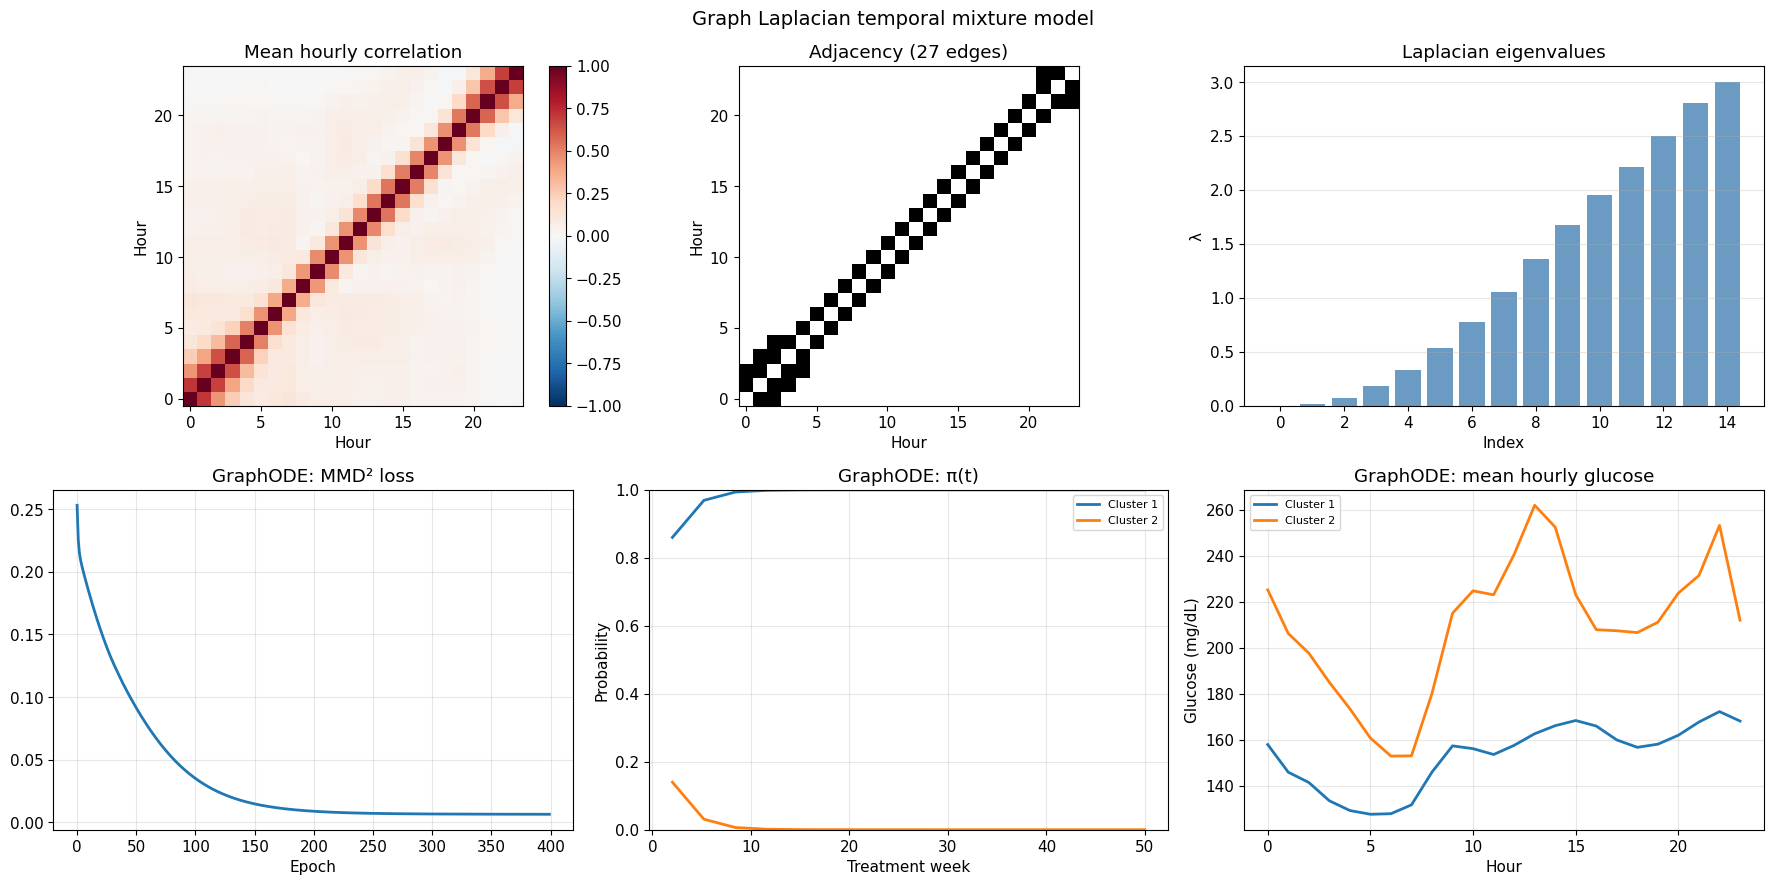

In [14]:
mean_corr = compute_mean_correlation(
    patient_data, window_size=14, stride=1, shrinkage=0.1, verbose=True
)
adj = threshold_to_adjacency(mean_corr, threshold=0.3)
graph_basis = GraphLaplacianBasis.from_adjacency(
    adjacency=torch.tensor(adj, device=device, dtype=dtype),
    alpha=0.1, num_eigenvectors=15, device=device, dtype=dtype,
)

hourly_sig, g_t, g_pids, g_wd, _ = compute_sliding_window_hourly(
    patient_data, window_size=7, stride=1, verbose=True
)
g_coeffs = graph_basis.project(
    torch.tensor(hourly_sig, device=device, dtype=dtype)
).detach().cpu().numpy()
g_rep = build_temporal_coefficients(g_coeffs, g_t, N_BINS, device, dtype)
sigma_g = estimate_sigma_median_heuristic(g_rep["X_time"], g_rep["mask"])

model_g, hist_g, pi_g = run_experiment(
    "GraphODE",
    NeuralODETimeWeights(g_rep["t_grid"], K, hidden_dim=64, device=device, dtype=dtype),
    g_rep["X_time"], GaussianKernel(sigma=max(1e-8, sigma_g)),
    K, g_rep["coeff_dim"], EPOCHS, LR, device, dtype, g_rep["mask"], verbose=True,
)

with torch.no_grad():
    recon_hourly = graph_basis.reconstruct(
        model_g.mean.cpu() * g_rep["coeff_std"].cpu() + g_rep["coeff_mean"].cpu()
    ).numpy()

t_weeks_g = (
    g_rep["t_grid"].cpu().numpy()
    * (g_rep["t_max_days"] - g_rep["t_min_days"]) + g_rep["t_min_days"]
) / 7.0

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Row 1: graph structure
im0 = axes[0, 0].imshow(mean_corr, cmap="RdBu_r", vmin=-1, vmax=1, origin="lower")
axes[0, 0].set(title="Mean hourly correlation", xlabel="Hour", ylabel="Hour")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046)

n_edges = int(adj.sum()) // 2
axes[0, 1].imshow(adj, cmap="Greys", origin="lower")
axes[0, 1].set(title=f"Adjacency ({n_edges} edges)", xlabel="Hour", ylabel="Hour")

eigs = graph_basis.eigenvalues.detach().cpu().numpy()
axes[0, 2].bar(range(len(eigs)), eigs, color="steelblue", alpha=0.8)
axes[0, 2].set(title="Laplacian eigenvalues", xlabel="Index", ylabel="λ")
axes[0, 2].grid(alpha=0.3, axis="y")

# Row 2: model results
axes[1, 0].plot(hist_g, lw=2)
axes[1, 0].set(title="GraphODE: MMD² loss", xlabel="Epoch")
axes[1, 0].grid(alpha=0.3)
for k in range(K):
    axes[1, 1].plot(t_weeks_g, pi_g.cpu().numpy()[:, k], lw=2, label=f"Cluster {k + 1}")
axes[1, 1].set(title="GraphODE: π(t)", xlabel="Treatment week", ylabel="Probability", ylim=(0, 1))
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)
for k in range(K):
    axes[1, 2].plot(np.arange(24), recon_hourly[k], lw=2, label=f"Cluster {k + 1}")
axes[1, 2].set(title="GraphODE: mean hourly glucose", xlabel="Hour", ylabel="Glucose (mg/dL)")
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(alpha=0.3)

plt.suptitle("Graph Laplacian temporal mixture model", fontsize=14)
plt.tight_layout()
plt.show()

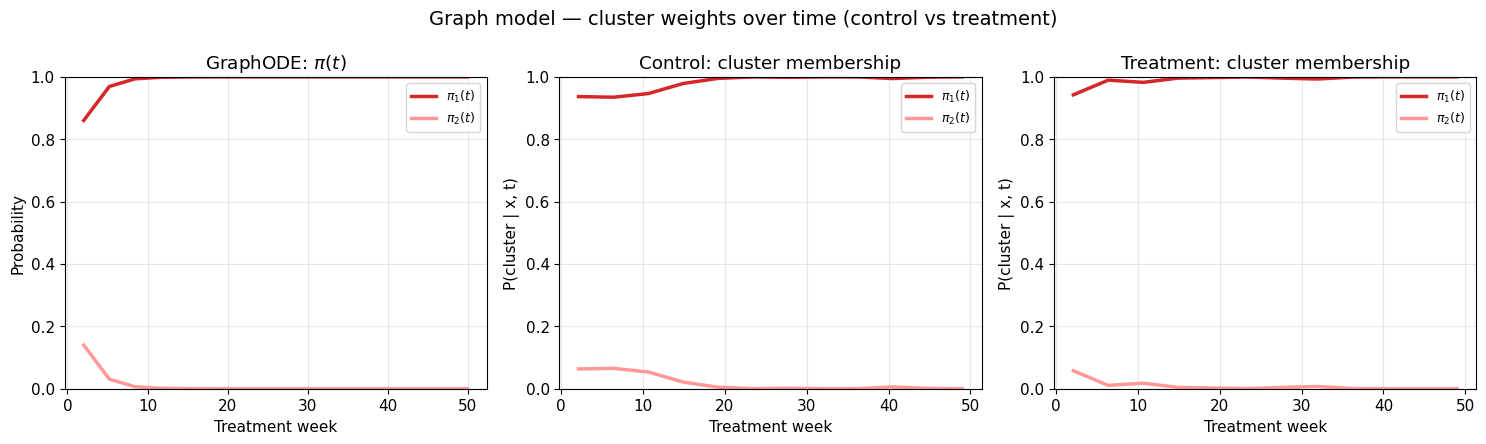

In [15]:
# ── Compute posteriors for graph model ───────────────────────────────────────
graph_post, graph_days_dict = _compute_posteriors_generic(
    hourly_sig, g_t, g_pids, g_wd,
    graph_basis,
    g_rep["coeff_mean"], g_rep["coeff_std"],
    g_rep["t_grid"], g_rep["t_min_days"], g_rep["t_max_days"],
    model_g, device, dtype,
)

# ── Bin by control / treatment ────────────────────────────────────────────────
ctrl_data_g, treat_data_g = [], []
for pid, post in graph_post.items():
    for i, day in enumerate(graph_days_dict[pid]):
        if pid in ctrl_set:
            ctrl_data_g.append((day, post[i]))
        elif pid in treat_set:
            treat_data_g.append((day, post[i]))

all_days_g = [d for d, _ in ctrl_data_g + treat_data_g]
bin_edges_g = np.linspace(min(all_days_g), max(all_days_g) + 1e-9, N_BINS_GRP + 1)
bin_weeks_g = ((bin_edges_g[:-1] + bin_edges_g[1:]) / 2.0) / 7.0

ctrl_means_g  = _bin_mean_c(ctrl_data_g,  bin_edges_g, N_BINS_GRP, K)
treat_means_g = _bin_mean_c(treat_data_g, bin_edges_g, N_BINS_GRP, K)

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap_g = matplotlib.colormaps.get_cmap("tab20")
t_weeks_g_plot = (
    g_rep["t_grid"].cpu().numpy()
    * (g_rep["t_max_days"] - g_rep["t_min_days"]) + g_rep["t_min_days"]
) / 7.0

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Left: global π(t)
for k in range(K):
    axes[0].plot(t_weeks_g_plot, pi_g.cpu().numpy()[:, k], lw=2.5,
                 color=cmap_g(6 + k), label=fr"$\pi_{{{k+1}}}(t)$")
axes[0].set(title=r"GraphODE: $\pi(t)$", xlabel="Treatment week",
            ylabel="Probability", ylim=(0, 1))
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Middle: control group posteriors
for k in range(K):
    ok = ~np.isnan(ctrl_means_g[:, k])
    axes[1].plot(bin_weeks_g[ok], ctrl_means_g[ok, k], lw=2.5,
                 color=cmap_g(6 + k), label=fr"$\pi_{{{k+1}}}(t)$")
axes[1].set(title="Control: cluster membership", xlabel="Treatment week",
            ylabel="P(cluster | x, t)", ylim=(0, 1))
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# Right: treatment group posteriors
for k in range(K):
    ok = ~np.isnan(treat_means_g[:, k])
    axes[2].plot(bin_weeks_g[ok], treat_means_g[ok, k], lw=2.5,
                 color=cmap_g(6 + k), label=fr"$\pi_{{{k+1}}}(t)$")
axes[2].set(title="Treatment: cluster membership", xlabel="Treatment week",
            ylabel="P(cluster | x, t)", ylim=(0, 1))
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle("Graph model — cluster weights over time (control vs treatment)", fontsize=14)
plt.tight_layout()
plt.savefig("../paper/images/graph_cluster_weights.pdf", dpi=300, bbox_inches="tight")
plt.show()
